# 06 · Deep learning in PyTorch

A PyTorch port of the [TensorFlow time-series tutorial](https://www.tensorflow.org/tutorials/structured_data/time_series). All building blocks live in `tsforecasting.models.deep`.

Neural networks learn $f_\theta$ in

$$\hat{\mathbf y}_{t+1:t+H} = f_\theta(\mathbf x_{t-w+1:t})$$

from **windows** of $w$ past steps of all features, by minimizing the MSE with stochastic gradient descent.

In [1]:
%load_ext autoreload
%autoreload 2
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
from tsforecasting.data.data_loader import load_airline, load_jena, temporal_split
from tsforecasting.features.build_features import TARGET

try:
    df = load_jena()
except FileNotFoundError:  # first run: download + clean + features
    from tsforecasting.data import make_dataset
    from tsforecasting.features import build_features
    make_dataset.main(); build_features.main()
    df = load_jena()
y = df[TARGET]
airline = load_airline()
df.shape, airline.shape

((70128, 19), (144,))

In [3]:
import torch
from tsforecasting.models.deep import (CNN, LSTM, Dense, FeedBack, MultiStepDense, Residual,
                                       WindowDataset, evaluate, fit)
from tsforecasting.models.foundation import get_device

torch.manual_seed(0)
device = get_device()
EPOCHS = 5  # raise to 20 for tutorial-level accuracy
print("device:", device)

device: cpu


## 1. Normalization

Neural networks train best on inputs of similar scale. We standardize every feature with **training-set statistics only**, $z = (x - \mu_{\text{train}})/\sigma_{\text{train}}$, so no information from the future leaks.

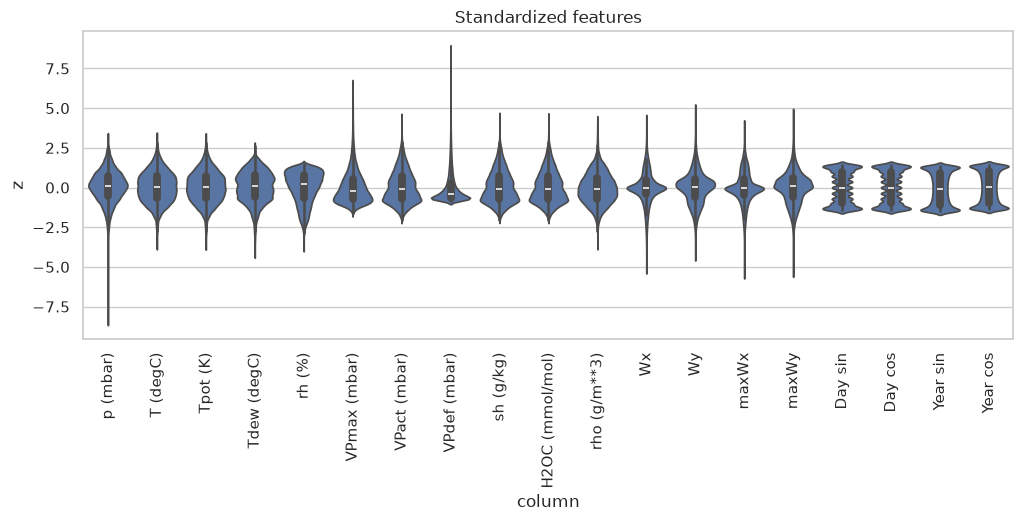

In [4]:
train_df, val_df, test_df = temporal_split(df)
mean, std = train_df.mean(), train_df.std()
norm = lambda d: (d - mean) / std
train_n, val_n, test_n = norm(train_df), norm(val_df), norm(test_df)

ax = sns.violinplot(data=norm(df).melt(var_name="column", value_name="z"), x="column", y="z", density_norm="width")
ax.tick_params(axis="x", rotation=90); ax.set_title("Standardized features");

## 2. Windows

`WindowDataset(df, input_width, label_width, shift)` cuts the series into (input, label) pairs. Two examples:

WindowDataset(total=48, inputs=[0..23], labels=[47..47], label_columns=['T (degC)'])
WindowDataset(total=7, inputs=[0..5], labels=[6..6], label_columns=['T (degC)'])


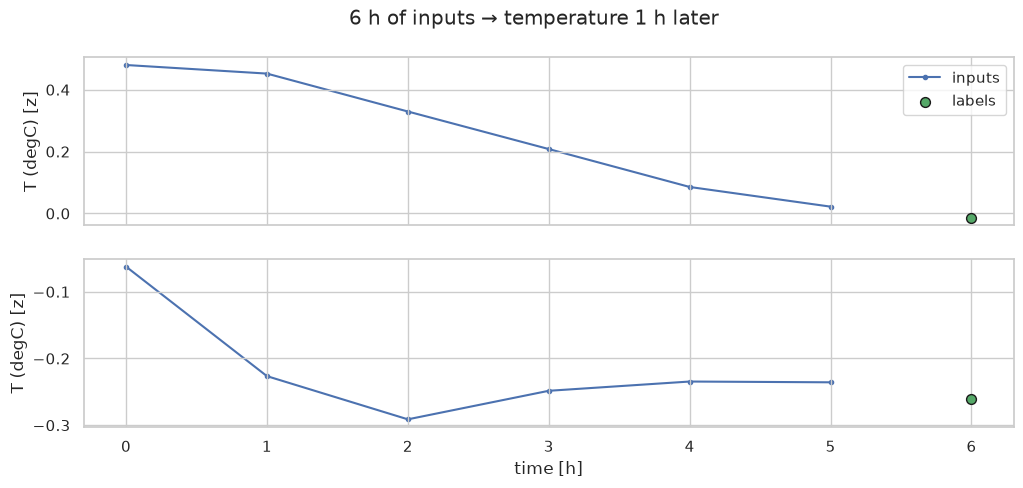

In [5]:
def plot_window(ds, model=None, n=3, col=TARGET):
    x, y = next(iter(ds.loader(batch_size=n, shuffle=True)))
    ci, li = ds.label_columns.index(col) if col in ds.label_columns else 0, list(train_df.columns).index(col)
    t_in = np.arange(ds.input_width)
    t_lab = np.arange(ds.total - ds.label_width, ds.total)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.4 * n), sharex=True)
    for i, ax in enumerate(axes):
        ax.plot(t_in, x[i, :, li], marker=".", label="inputs", zorder=-1)
        ax.scatter(t_lab, y[i, :, ci], edgecolors="k", c="C2", s=50, label="labels")
        if model is not None:
            with torch.no_grad():
                p = model.to("cpu")(x)[i, :, ci]
            ax.scatter(t_lab[-len(p):], p, marker="X", edgecolors="k", c="C1", s=50, label="predictions")
        ax.set_ylabel(f"{col} [z]")
    axes[0].legend(); axes[-1].set_xlabel("time [h]")
    return fig

w1 = WindowDataset(train_n, input_width=24, label_width=1, shift=24, label_columns=[TARGET]); print(w1)
w2 = WindowDataset(train_n, input_width=6, label_width=1, shift=1, label_columns=[TARGET]); print(w2)
plot_window(w2, n=2).suptitle("6 h of inputs → temperature 1 h later");

## 3. Single-step models: predict $y_{t+1}$

We train on a **wide window** (24 inputs, 24 labels shifted by 1). A per-time-step model then makes 24 independent one-step predictions per window, which is efficient and gives nicer plots.

| model | $\hat y_{t+1}$ |
|---|---|
| baseline | $y_t$ |
| linear | $\mathbf w^\top \mathbf x_t + b$ |
| dense | $\text{MLP}(\mathbf x_t)$ |
| multi-step dense | $\text{MLP}(\text{flatten}(\mathbf x_{t-2:t}))$ |
| CNN | $\text{MLP}(\text{Conv1D}_{k=3}(\mathbf x_{t-2:t}))$ |
| LSTM | $W\mathbf h_t$, with $\mathbf h_t = \text{LSTM}(\mathbf x_t, \mathbf h_{t-1})$ |

In [6]:
F = train_n.shape[1]
make = lambda d, iw, lw, sh, lab=(TARGET,): WindowDataset(d, iw, lw, sh, list(lab) if lab else None)
wide = {k: make(d, 24, 24, 1) for k, d in [("train", train_n), ("val", val_n), ("test", test_n)]}
conv = {k: make(d, 3, 1, 1) for k, d in [("train", train_n), ("val", val_n), ("test", test_n)]}
wide_conv = {k: make(d, 24 + 2, 24, 1) for k, d in [("train", train_n), ("val", val_n), ("test", test_n)]}

class LastValue(torch.nn.Module):
    def forward(self, x):
        return x[..., [train_df.columns.get_loc(TARGET)]]

def train_eval(model, win, epochs=EPOCHS):
    hist = fit(model, win["train"].loader(256), win["val"].loader(256, shuffle=False), epochs=epochs, device=device)
    return hist, evaluate(model, win["val"].loader(256, False), device)["mae"], evaluate(model, win["test"].loader(256, False), device)["mae"]

single = {}
single["baseline"] = (None, evaluate(LastValue(), wide["val"].loader(256, False))["mae"], evaluate(LastValue(), wide["test"].loader(256, False))["mae"])
single["linear"] = train_eval(lin := Dense(F, 1), wide)
single["dense"] = train_eval(Dense(F, 1, hidden=(64, 64)), wide)
single["multi-step dense"] = train_eval(MultiStepDense(F, 3, 1, out_steps=1), conv)
single["cnn"] = train_eval(cnn := CNN(F, 1, kernel_size=3), wide_conv)
single["lstm"] = train_eval(lstm := LSTM(F, 1), wide)

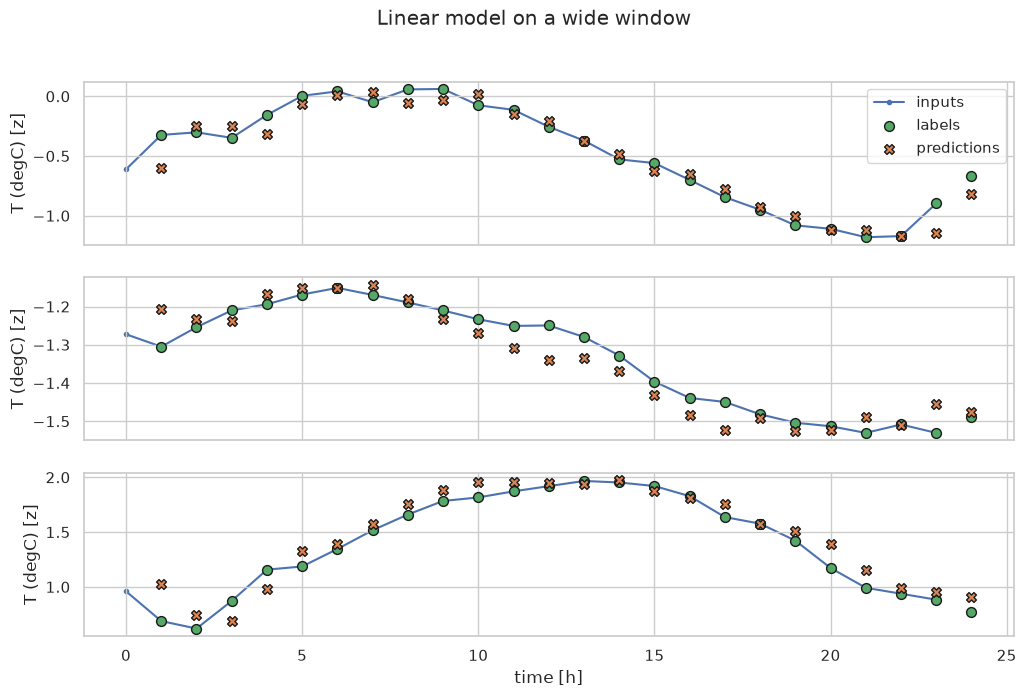

In [7]:
plot_window(wide["train"], lin).suptitle("Linear model on a wide window");

The linear model is interpretable: its weights tell us which current features drive next-hour temperature.

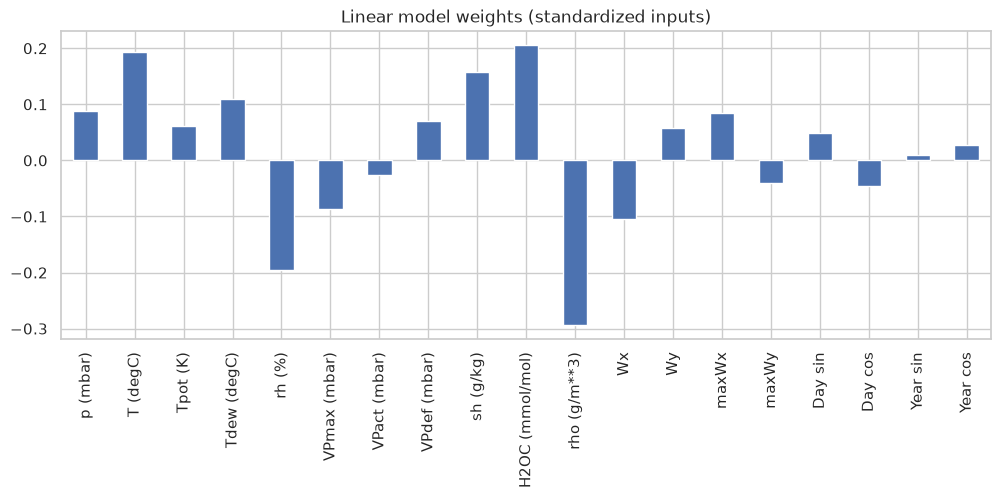

In [8]:
w = lin.net[0].weight.detach().cpu().numpy()[0]
pd.Series(w, index=train_df.columns).plot.bar(title="Linear model weights (standardized inputs)");

### Learning curves and comparison

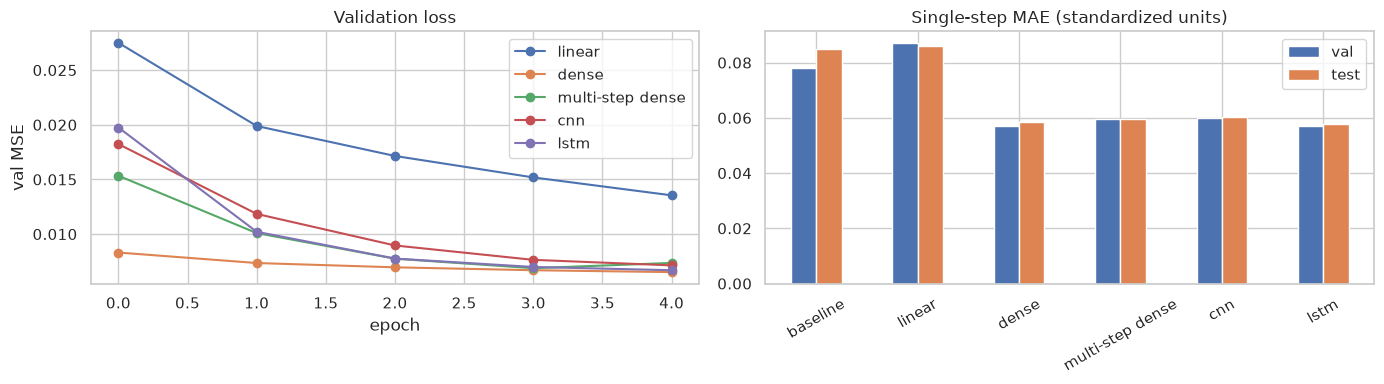

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for k, (h, *_) in single.items():
    if h:
        axes[0].plot(h["val_mse"], marker="o", label=k)
axes[0].set(xlabel="epoch", ylabel="val MSE", title="Validation loss"); axes[0].legend()
perf = pd.DataFrame({k: {"val": v, "test": t} for k, (_, v, t) in single.items()}).T
perf.plot.bar(ax=axes[1], title="Single-step MAE (standardized units)", rot=30)
fig.tight_layout()

## 4. Multi-step models: predict the next 24 h

Now input 24 h and output 24 h ($H = 24$).

- **Single-shot** models emit all $H$ values at once from a representation of the window, $\hat{\mathbf y}_{t+1:t+H} = W\,\text{enc}(\mathbf x_{t-23:t})$.
- The **autoregressive** `FeedBack` model warms up an LSTM on the inputs. It then feeds each prediction back as the next input, $\hat{\mathbf x}_{t+1} = g(\mathbf h_t)$, $\mathbf h_{t+1}=\text{LSTMCell}(\hat{\mathbf x}_{t+1}, \mathbf h_t)$. This is the same recursive strategy as in notebook 04, learned end to end.

In [10]:
H = 24
ms = {k: make(d, 24, H, H, None) for k, d in [("train", train_n), ("val", val_n), ("test", test_n)]}  # all features

class RepeatLast(torch.nn.Module):
    def forward(self, x):
        return x[:, -1:, :].repeat(1, H, 1)

class RepeatDay(torch.nn.Module):
    def forward(self, x):
        return x

multi = {}
for k, m in {"last": RepeatLast(), "repeat yesterday": RepeatDay()}.items():
    multi[k] = (None, evaluate(m, ms["val"].loader(256, False))["mae"], evaluate(m, ms["test"].loader(256, False))["mae"])
multi["linear"] = train_eval(MultiStepDense(F, 1, F, H, hidden=()), {k: make(d, 1, H, H, None) for k, d in
                             [("train", train_n), ("val", val_n), ("test", test_n)]})
multi["dense"] = train_eval(MultiStepDense(F, 24, F, H, hidden=(512,)), ms)
multi["cnn"] = train_eval(CNN(F, F, kernel_size=3, out_steps=H, channels=256), ms)
multi["lstm"] = train_eval(lstm_ms := LSTM(F, F, hidden=32, out_steps=H), ms)
multi["autoregressive lstm"] = train_eval(ar := FeedBack(F, out_steps=H, hidden=32), ms)

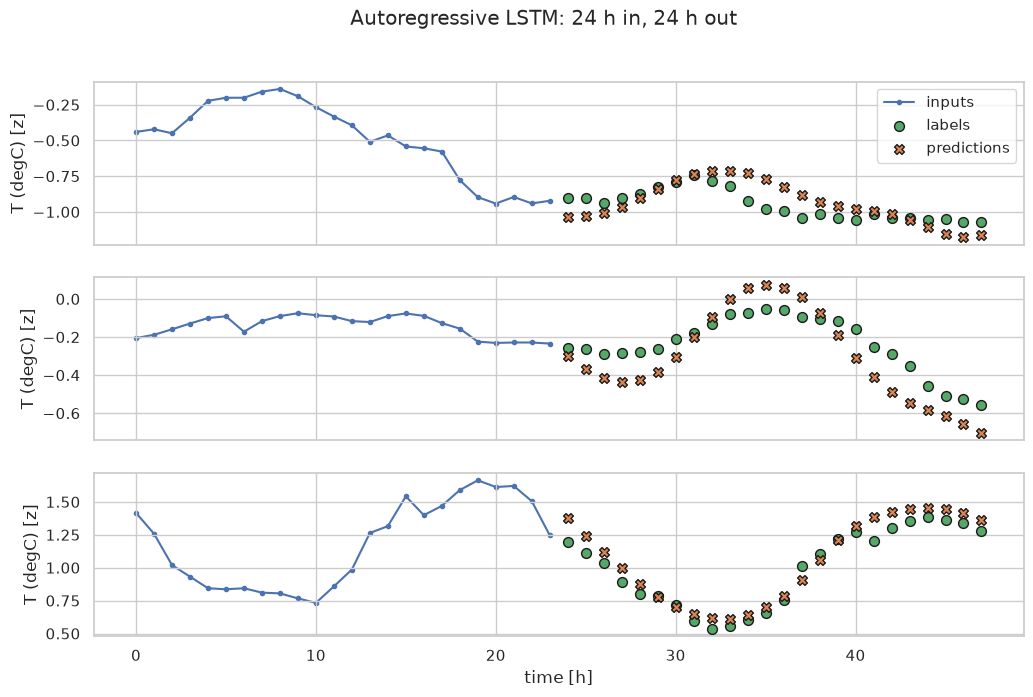

In [11]:
plot_window(ms["train"], ar, col=TARGET).suptitle("Autoregressive LSTM: 24 h in, 24 h out");

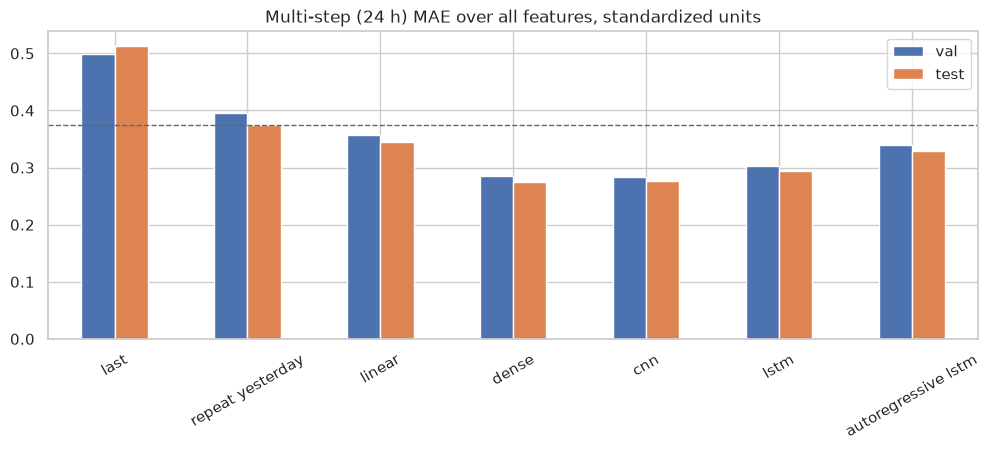

In [12]:
perf = pd.DataFrame({k: {"val": v, "test": t} for k, (_, v, t) in multi.items()}).T
ax = perf.plot.bar(rot=30, title="Multi-step (24 h) MAE over all features, standardized units")
ax.axhline(perf.loc["repeat yesterday", "test"], color="0.4", ls="--", lw=1);

## 5. Residual connections

For slowly-varying signals it is easier to learn the **change** than the level: $\hat y_{t+1} = y_t + f_\theta(\mathbf x_t)$. Initializing $f_\theta$ near zero makes the untrained model equal to the persistence baseline, so training starts from a sensible place.

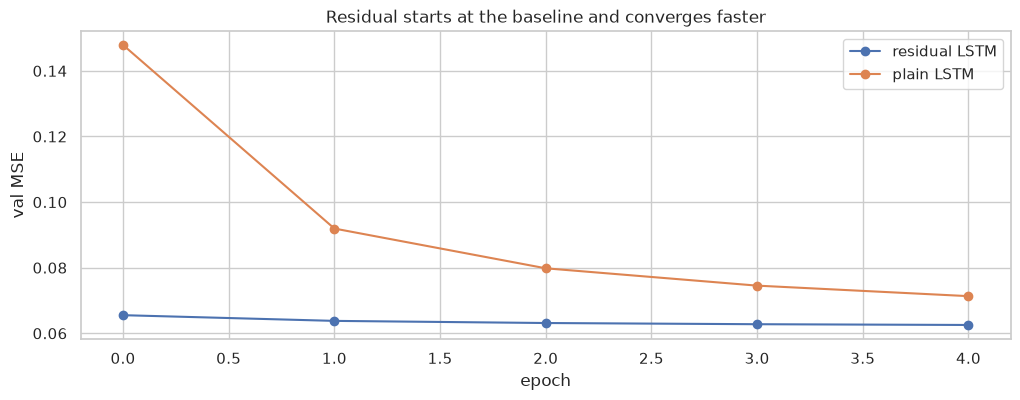

In [13]:
res_lstm = LSTM(F, F)
torch.nn.init.zeros_(res_lstm.head.weight); torch.nn.init.zeros_(res_lstm.head.bias)
wide_all = {k: make(d, 24, 24, 1, None) for k, d in [("train", train_n), ("val", val_n), ("test", test_n)]}
h_res, v_res, t_res = train_eval(Residual(res_lstm), wide_all)
h_plain, v_plain, t_plain = train_eval(LSTM(F, F), wide_all)
plt.plot(h_res["val_mse"], marker="o", label="residual LSTM"); plt.plot(h_plain["val_mse"], marker="o", label="plain LSTM")
plt.xlabel("epoch"); plt.ylabel("val MSE"); plt.legend(); plt.title("Residual starts at the baseline and converges faster");

## Takeaways
- Windowing turns a series into a supervised dataset. Input width, label width and shift define the task.
- Deep models need normalization, early stopping and a validation set. They only beat simple baselines with enough data and epochs.
- Single-shot vs autoregressive mirrors the direct vs recursive trade-off of notebook 04.
- `get_device()` decides CPU vs GPU. On this machine these small models train comfortably on CPU.